Get node labels

In [1]:
import sys
sys.path.append('..')
import data_utils
sys.path.append(data_utils.join_base_path('reallaborai4u/preprocessing'))
from feature_names import NON_CONDITIONAL_FEAT as LABELS
PRINT_LABELS = [l.removeprefix('EMA_') for l in LABELS]

Settings

In [ ]:
from ema_forecast_control.utils import path_utils, model_catalogue

SAVE = False

project_name = f'v3_MRT3_every_day_latest'

labels = ['EMA_mood','EMA_disappointed','EMA_scared','EMA_worry',
    'EMA_down','EMA_sad','EMA_confidence','EMA_stress','EMA_lonely',
    'EMA_energetic','EMA_concentration','EMA_resilience','EMA_tired',
    'EMA_satisfied', 'EMA_relaxed']

models = model_catalogue.ModelCatalogue(project_name)
test_data_dir = path_utils.join_base_path('data/AI4U_sample3')

### PLRNN

Calculate cumulative impulse responses for inputs targeted at single nodes

In [ ]:
import sys
sys.path.append('..')
import os
import torch as tc
import matplotlib.pyplot as plt

from ema_forecast_control._ai4u_utils.ai4u_utils import determine_model_class
from ema_forecast_control.utils import network_utils
from ema_forecast_control.plrnn.plrnn_model import PLRNN

T = 7

errors_loading_model = 0

plrnn_out_centrality = []
plrnn_abs_out_centrality = []
plrnn_cir = []
plrnn_input_selectivity_new = []
plrnn_input_selectivity_old = []


mrt_out_centrality = []
mrt_abs_out_centrality = []
mrt_cir = []
mrt_input_selectivity_new = []
mrt_input_selectivity_old = []

for p, df in path_utils.zip_participants_data(test_data_dir):
    model_dir = models.get_best_latest_model_dir(p, timestep=1000)
    if model_dir is None:
        continue
    args = path_utils.load_args(model_dir)
    if path_utils.determine_model_class(args) != 'PLRNN':
        raise ValueError('Model is not PLRNN')
    model = PLRNN()
    model.init_from_model_path(model_dir)
    try:
        Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
    except:
        errors_loading_model += 1
        continue
    x = tc.tensor(df[labels].to_numpy()).float()
    network = network_utils.get_network_matrix(model, x, Gamma=Gamma, B=B).nanmean(0)
    model_out_centrality = network_utils.weighted_degree_centrality(network, mode='out', absolute=False)
    model_abs_out_centrality = network_utils.weighted_degree_centrality(network, mode='out', absolute=True)
    perturb_nodes = tc.arange(len(model_out_centrality))
    C = model.get_parameters()['C']
    
    model_cir = []
    model_input_selectivity_new = []
    model_input_selectivity_old = []
    x0 = tc.cat((tc.eye(x.shape[1]).float(), tc.zeros(x.shape[1]).float().unsqueeze(0)), 0)
    for i, item in enumerate(perturb_nodes):
        ## Old version of perturbation:
        B_reduced = B[item]
        if B_reduced.ndim == 1:
            B_reduced = B_reduced.unsqueeze(0)
            M = B_reduced @ C
            kernel_basis, compl_basis = eval_reallabor_utils.split_basis_into_kernel_and_orthogonal_complement(M)
            perturbation_old = compl_basis.mean(dim=1) * 1
            subject_input_selectivity_old = eval_reallabor_utils.impulse_selectivity_score(B, C, perturbation_old, item).detach()
            ## New version of perturbation 
            perturbation = eval_reallabor_utils.target_input_on_node(B, C, item)
            subject_input_selectivity_new = eval_reallabor_utils.impulse_selectivity_score(B, C, perturbation, item).detach()
            subject_cir = eval_reallabor_utils.impulse_response(model, perturbation, T, cumulative=True, relative=True, x0=x0, 
                                                                Gamma=Gamma, B=B).mean(axis=0)     # mean over initial conditions
            model_cir.append(subject_cir)
            model_input_selectivity_new.append(subject_input_selectivity_new)
            model_input_selectivity_old.append(subject_input_selectivity_old)
        model_cir = tc.stack(model_cir, dim=0)
        mrt_cir.append(model_cir)
        model_input_selectivity_new = tc.stack(model_input_selectivity_new, dim=0)
        mrt_input_selectivity_new.append(model_input_selectivity_new)
        model_input_selectivity_old = tc.stack(model_input_selectivity_old, dim=0)
        mrt_input_selectivity_old.append(model_input_selectivity_old)
        mrt_out_centrality.append(model_out_centrality)
        mrt_abs_out_centrality.append(model_abs_out_centrality)

    mrt_cir = tc.stack(mrt_cir, dim=0)
    plrnn_cir.append(mrt_cir)
    mrt_input_selectivity_new = tc.stack(mrt_input_selectivity_new, dim=0)
    plrnn_input_selectivity_new.append(mrt_input_selectivity_new)
    mrt_input_selectivity_old = tc.stack(mrt_input_selectivity_old, dim=0)
    plrnn_input_selectivity_old.append(mrt_input_selectivity_old)
    mrt_out_centrality = tc.stack(mrt_out_centrality, dim=0)
    mrt_abs_out_centrality = tc.stack(mrt_abs_out_centrality, dim=0)
    plrnn_out_centrality.append(mrt_out_centrality)
    plrnn_abs_out_centrality.append(mrt_abs_out_centrality)

if errors_loading_model > 0:
    print(f'Errors loading model: {errors_loading_model}')
### dims of plrnn_cir: (mrt, subject, perturb_node, feature)
### dims of plrnn_out_centrality: (mrt, subject, perturb_node)

Perturbation analysis for MRT 2....
Perturbation analysis for MRT 3....
Errors loading model: 1


In [4]:
from scipy import stats

for m, mrt in enumerate(MRT):
    print(f'New selectivity mean MRT {mrt}: {plrnn_input_selectivity_new[m].mean()}')
    print(f'Old selectivity mean MRT {mrt}: {plrnn_input_selectivity_old[m].mean()}')

    selectivity_test = stats.ttest_rel(plrnn_input_selectivity_new[m].mean(1), plrnn_input_selectivity_old[m].mean(1))
    print(f'Selectivity t-test MRT {mrt}: t={selectivity_test.statistic}, p={selectivity_test.pvalue}')

New selectivity mean MRT 2: 0.2158830463886261
Old selectivity mean MRT 2: 0.13503612577915192
Selectivity t-test MRT 2: t=26.047921962040352, p=2.983076037757134e-32
New selectivity mean MRT 3: 0.2160782665014267
Old selectivity mean MRT 3: 0.12960053980350494
Selectivity t-test MRT 3: t=36.504985232951725, p=1.0320762819468166e-41


Plot out centrality of nodes against cumulative impulse reponse

Low vs. high rank nodes t-test MRT 2: t(54)=-4.508841873333512, p=3.546915644407708e-05
Correlation between out centrality rank and rCIR:
MRT 2, rank r=0.889, p=0.000
Low vs. high rank nodes t-test MRT 3: t(58)=-4.874173608557506, p=8.843346637973798e-06
Correlation between out centrality rank and rCIR:
MRT 3, rank r=0.829, p=0.000


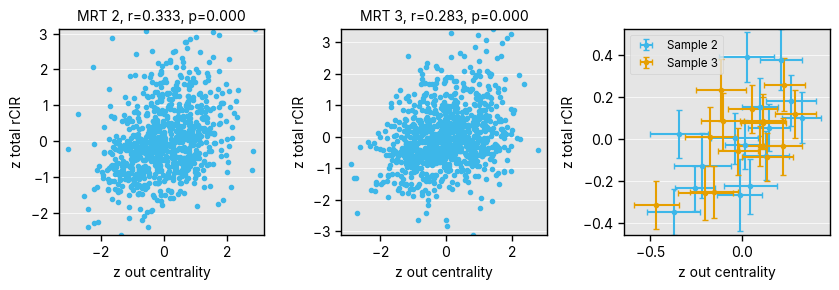

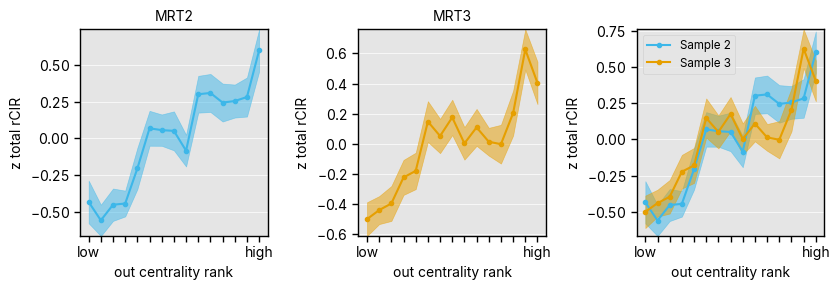

In [14]:
from scipy import stats
import math

take_absolute_cir = False
standardize_cir = True
standardize_centrality = True
cir = plrnn_cir.copy()
out_centrality = plrnn_out_centrality.copy()

color_cycle = colors.color_cycle[:2]#["#3DB7E9", "#e69f00"]
with PaperStyle():
    fig1, axes1 = plt.subplots(1, 3, figsize=(8.5, 3), sharey=False)
    fig2, axes2 = plt.subplots(1, 3, figsize=(8.5, 3), sharey=False)
    for m, mrt in enumerate(MRT):
        valid_map = ~cir[m].mean(2).isnan().any(1)
        # standardize out centrality over nodes
        if standardize_centrality:
            z_out_centrality = (out_centrality[m] - out_centrality[m].mean(1, keepdim=True)) / out_centrality[m].std(1, keepdim=True)
            label_out_centrality = 'z out centrality'
        else:
            z_out_centrality = out_centrality[m]
            label_out_centrality = 'out centrality'
        z_out_centrality = z_out_centrality[valid_map]
        # standardize cir over perturb_nodes
        if take_absolute_cir:
            cir_mean = tc.abs(cir[m]).mean(2)[valid_map]
            label_cir = 'total abs rCIR'
        else:
            cir_mean = cir[m].mean(2)[valid_map]
            label_cir = 'total rCIR'
        if standardize_cir:
            z_total_cir = (cir_mean - cir_mean.mean(1, keepdim=True)) / cir_mean.std(1, keepdim=True)
            label_cir = 'z ' + label_cir
        else:
            z_total_cir = cir_mean
        pearsonr = stats.pearsonr(z_out_centrality.flatten(), z_total_cir.flatten())
        r, p = pearsonr.correlation, pearsonr.pvalue
        axes1[m].plot(z_out_centrality.flatten(), z_total_cir.flatten(), linestyle='', marker='.')
        axes1[m].set(xlabel=label_out_centrality, ylabel=label_cir, title=f'MRT {mrt}, r={r:.3f}, p={p:.3f}')
        axes1[2].errorbar(z_out_centrality.mean(0), z_total_cir.mean(0), 
                          yerr=z_total_cir.std(0)/math.sqrt(z_total_cir.shape[0]), 
                          xerr=z_out_centrality.std(0)/math.sqrt(z_out_centrality.shape[0]), color=color_cycle[m], linestyle='', marker='.', label=f'Sample {mrt}')
        axes1[2].set(xlabel=label_out_centrality, ylabel=label_cir)
        axes1[2].legend()
        fig1.tight_layout()

        ordered_cir_mean = z_total_cir.take_along_dim(z_out_centrality.argsort(), dim=1)
        ordered_cir_mean_mean = ordered_cir_mean.mean(0)
        ordered_cir_mean_sem = ordered_cir_mean.std(0) / math.sqrt(ordered_cir_mean.shape[0])
        rankcorr = stats.spearmanr(range(ordered_cir_mean.shape[1]), ordered_cir_mean_mean)
        r, p = rankcorr.correlation, rankcorr.pvalue
        axes2[m].plot(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean, linestyle='-', marker='.', color=color_cycle[m])
        axes2[m].fill_between(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean - ordered_cir_mean_sem, ordered_cir_mean_mean + ordered_cir_mean_sem, alpha=0.5, color=color_cycle[m])
        axes2[m].set(xlabel='out centrality rank', ylabel=label_cir, title=f'MRT{mrt}')
        axes2[m].set_xticks(tc.arange(ordered_cir_mean.shape[1])+1, labels=['low']+['']*(ordered_cir_mean.shape[1]-2)+['high'])
        axes2[2].plot(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean, linestyle='-', marker='.', color=color_cycle[m], label=f'Sample {mrt}')
        axes2[2].fill_between(tc.arange(ordered_cir_mean.shape[1])+1, ordered_cir_mean_mean - ordered_cir_mean_sem, ordered_cir_mean_mean + ordered_cir_mean_sem, alpha=0.5, color=color_cycle[m])
        axes2[2].set(xlabel='out centrality rank', ylabel=label_cir)
        axes2[2].set_xticks(tc.arange(ordered_cir_mean.shape[1])+1, labels=['low']+['']*(ordered_cir_mean.shape[1]-2)+['high'])
        axes2[2].legend()
        fig2.tight_layout()

        # Test highest vs lowest rank node rCIRs
        high_rank_nodes = ordered_cir_mean[:, 0]
        low_rank_nodes = ordered_cir_mean[:, -1]
        rank_nodes_test = stats.ttest_rel(high_rank_nodes, low_rank_nodes)
        print(f'Low vs. high rank nodes t-test MRT {mrt}: t({rank_nodes_test.df})={rank_nodes_test.statistic}, p={rank_nodes_test.pvalue}')

        print('Correlation between out centrality rank and rCIR:')
        print(f'MRT {mrt}, rank r={r:.3f}, p={p:.3f}')
    if SAVE:
        fig2.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_cir_vs_out_centrality_rank.svg')
    plt.show()

Just rCIR

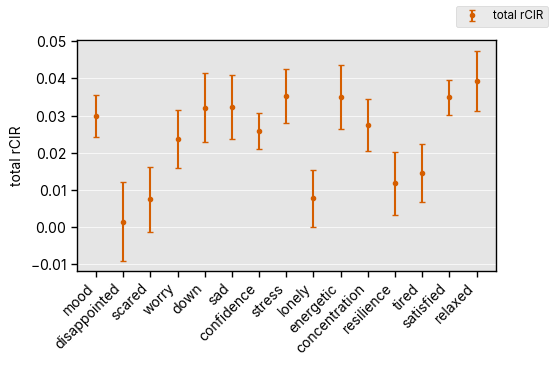

In [14]:
from scipy import stats
import math
from plotting_utils import adjust_ylim

take_absolute_cir = False
standardize_cir = False
cir = plrnn_cir.copy()

cir = tc.concat(cir, dim=0)

color_cycle = colors.color_cycle
with PaperStyle():
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    valid_map = ~cir.mean(2).isnan().any(1)
    if take_absolute_cir:
        cir_mean = tc.abs(cir).mean(2)[valid_map]
        label_cir = 'total abs rCIR'
    else:
        cir_mean = cir.mean(2)[valid_map]
        label_cir = 'total rCIR'
    if standardize_cir:
        z_total_cir = (cir_mean - cir_mean.mean(1, keepdim=True)) / cir_mean.std(1, keepdim=True)
        label_cir = 'z ' + label_cir
    else:
        z_total_cir = cir_mean
    cir_participant_mean = z_total_cir.mean(0)
    cir_participant_sem = z_total_cir.std(0) / math.sqrt(z_total_cir.shape[0])
    ax.set(ylabel=label_cir)    
    ax.errorbar(tc.arange(len(PRINT_LABELS)), cir_participant_mean, yerr=cir_participant_sem, linestyle='', marker='.', color=color_cycle[5], label=label_cir)
    ax.set_xticks(tc.arange(len(PRINT_LABELS)), PRINT_LABELS, rotation=45, ha='right')
    adjust_ylim(ax)
    fig.legend()
    if SAVE:
        fig.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_cir.svg')
    plt.show()

Just selectivity

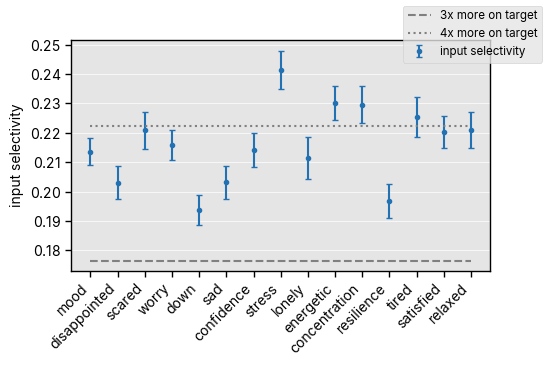

In [15]:
from scipy import stats
import math
from plotting_utils import adjust_ylim

selectivity = plrnn_input_selectivity_new.copy()
selectivity = tc.concat(selectivity, dim=0)

color_cycle = colors.color_cycle
with PaperStyle():
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3))
    selectivity_participant_mean = selectivity.mean(0)
    selectivity_participant_sem = selectivity.std(0) / math.sqrt(selectivity.shape[0])
    triple_selectivity = 3 / (selectivity.shape[1]+2)
    quadruple_selectivity = 4 / (selectivity.shape[1]+3)
    # quintuple_selectivity = 5 / (selectivity.shape[1]+4)
    ax.set(ylabel='input selectivity')    
    ax.errorbar(tc.arange(len(PRINT_LABELS)), selectivity_participant_mean, yerr=selectivity_participant_sem, linestyle='', marker='.', color=color_cycle[4], label='input selectivity')
    x_lim = [0, len(PRINT_LABELS)-1]
    ax.plot(x_lim, [triple_selectivity, triple_selectivity], linestyle='--', color='gray', label='3x more on target')
    ax.plot(x_lim, [quadruple_selectivity, quadruple_selectivity], linestyle=':', color='gray', label='4x more on target')
    # ax.plot(x_lim, [quintuple_selectivity, quintuple_selectivity], linestyle='--', color='blue', label='5x more on target')
    ax.set_xticks(tc.arange(len(PRINT_LABELS)), PRINT_LABELS, rotation=45, ha='right')
    adjust_ylim(ax)
    fig.legend()
    if SAVE:
        fig.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_input_selectivity.svg')
    plt.show()